In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
import cooler
import cooltools
from cooltools import insulation

from packaging import version
if version.parse(cooltools.__version__) < version.parse('0.5.4'):
    raise AssertionError("tutorials rely on cooltools version 0.5.4 or higher,"+
                         "please check your cooltools version and update to the latest")

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
data_dir = '/tank/projects/kashuk_sirt6_hic/bal_comb_10k/'
wt_clr = cooler.Cooler(f'{data_dir}/bal_sampled_WT_10k.cool')
old_clr = cooler.Cooler(f'{data_dir}/bal_sampled_old_10k.cool')
ko_clr = cooler.Cooler(f'{data_dir}/bal_sampled_KO_10k.cool')

con_clr = cooler.Cooler(f'{data_dir}/bal_sampled_control_10k.cool')
s1_clr = cooler.Cooler(f'{data_dir}/bal_sampled_step1_10k.cool')
s2_clr = cooler.Cooler(f'{data_dir}/bal_sampled_step2_10k.cool')

In [6]:
resolution = 10000
windows = [5*resolution]
adl_insulation = insulation(wt_clr, windows, verbose=False, ignore_diags=1)
old_insulation = insulation(old_clr, windows, verbose=False, ignore_diags=1)
ko_insulation = insulation(ko_clr, windows, verbose=False, ignore_diags=1)

con_insulation = insulation(con_clr, windows, verbose=False, ignore_diags=1)
s1_insulation = insulation(s1_clr, windows, verbose=False, ignore_diags=1)
s2_insulation = insulation(s2_clr, windows, verbose=False, ignore_diags=1)

INFO:root:fallback to serial implementation.
INFO:root:fallback to serial implementation.
INFO:root:fallback to serial implementation.
INFO:root:fallback to serial implementation.
INFO:root:fallback to serial implementation.
INFO:root:fallback to serial implementation.


In [41]:
import bioframe
import numpy as np
import pandas as pd

# constants
start, end = 1_000_000, 300_000_000
chromosomes = [f"chr{i}" for i in range(1,20)] + ["chrX","chrY"]
window = 50000   

def get_merged_boundaries(insulation_table, window=50000):
    """
    Given a insulation_table dataframe,
    returns a DataFrame of all (chrom, start, end) boundary pairs.
    """
    merged = []
    bs_col   = f"boundary_strength_{window}"
    flag_col = f"is_boundary_{window}"
    
    for chrom in chromosomes:
        region       = (chrom, start, end)
        ins_region   = bioframe.select(insulation_table, region)
        keep         = ins_region[~np.isnan(ins_region[bs_col])]
        keep         = keep[ keep[flag_col] ]
        
        if keep.shape[0] < 2:
            continue
        
        starts = keep["start"].to_numpy()
        ends   = keep["end"].to_numpy()
        ins_score = keep['log2_insulation_score_50000'].to_numpy()
        evens  = np.arange(1, len(starts), 2)  # 0‑based even indices
        
        # replace even positions with the corresponding end
        starts[evens] = ends[evens]
        
        # build the sliding pairs
        df_chr = pd.DataFrame({
            "chr":   chrom,
            "start": starts[:-1],
            "end":   starts[1:] - 1,
            "ins_score": ins_score[:-1]
        })
        merged.append(df_chr)
    
    return pd.concat(merged, ignore_index=True)

merged_adl = get_merged_boundaries(adl_insulation)
merged_old = get_merged_boundaries(old_insulation)
merged_ko  = get_merged_boundaries(ko_insulation)

merged_con  = get_merged_boundaries(con_insulation)
merged_s1  = get_merged_boundaries(s1_insulation)
merged_s2  = get_merged_boundaries(s2_insulation)

In [8]:
print(len(merged_adl))
print(len(merged_old))
print(len(merged_ko))

print(len(merged_con))
print(len(merged_s1))
print(len(merged_s2))

11502
10790
11067
11754
12256
10957


## Average TAD

In [9]:
import cooltools
import cooler
from tqdm import tqdm
from os.path import basename, splitext
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from collections.abc import Iterable
import bioframe
import gc
import subprocess
import itertools
import pysam
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.colors import Normalize, LogNorm
from matplotlib import ticker
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns
import coolpuppy
from coolpuppy import coolpup
import cooler

In [11]:
mm10_arms = pd.read_csv('mm10_arms.csv', index_col=0)

In [12]:
from cooltools import expected_cis

CLRS = [wt_clr, old_clr, ko_clr, con_clr, s1_clr, s2_clr]

results = [
    expected_cis(
        clr,
        ignore_diags=0,
        view_df=mm10_arms,
        chunksize=1_000_000,
        nproc=15
    )
    for clr in CLRS
]

expected_adl, expected_old, expected_ko, expected_con, expected_s1, expected_s2 = results

INFO:root:creating a Pool of 15 workers
INFO:root:creating a Pool of 15 workers
INFO:root:creating a Pool of 15 workers
INFO:root:creating a Pool of 15 workers
INFO:root:creating a Pool of 15 workers
INFO:root:creating a Pool of 15 workers


In [13]:
def prepare_tad_file(tad_file):
    """ Prepares the TAD file by selecting the necessary columns. """
    return tad_file[["chrom", "start", "end"]]

def create_average_tad_borders_both(treatment_tad_boundary_file, 
                                    control_tad_boundary_file, 
                                    treatment_cooler, 
                                    control_cooler, 
                                    expected_contact_maps, 
                                    map_resolution):
    """ 
    Constructs the average TAD self-border for both treatment and control Hi-C cooler files.
    
    Args:
        tad_boundary_file: File containing TAD boundaries (columns: chrom, start, end).
        treatment_cooler: Cooler file for treatment conditions.
        control_cooler: Cooler file for control conditions.
        expected_contact_maps: List of expected contact maps for treatment and control.
        map_resolution: The resolution for analysis.
        
    Returns:
        average_borders: List of averaged TAD border pileups for treatment and control.
    """
    processed_tad_file_treatment = prepare_tad_file(treatment_tad_boundary_file)
    processed_tad_file_control = prepare_tad_file(control_tad_boundary_file)
    
    average_borders = []
    coolers = [treatment_cooler, control_cooler]
    processed_tads = [processed_tad_file_treatment, processed_tad_file_control]
    
 
    for index, cooler, processed_tad_file in zip(range(len(coolers)), coolers, processed_tads):
        coord_creator = coolpup.CoordCreator(processed_tad_file, resolution=map_resolution, features_format='bed', local=True, rescale_flank=1)
        
        # Generate pileup 
        pile_upper = coolpup.PileUpper(cooler, coord_creator, expected=expected_contact_maps[index], 
                                        view_df=mm10_arms, ignore_diags=0, 
                                        rescale_size=99, rescale=True)
        
        pileups_result = pile_upper.pileupsWithControl(nproc=10)
        average_borders.append((pileups_result.data)[0])  # Only take the first pileup data
    return average_borders

def create_plot_indices():
    """ Generates a list of x and y indices for visualization. """
    x_indices = []
    y_indices = []    
    x_initial = 32
    y_initial = 33    
    x_current = x_initial
    y_current = y_initial
    limit = 66
    for _ in range(33):
        while x_current < limit:
            x_indices.append(x_current)
            y_indices.append(y_current)
            x_current += 1
        y_current += 1
        x_initial += 1
        x_current = x_initial
    return x_indices, y_indices

def extract_plot_values(average_tad):
    """ Retrieves values from average TAD pileups using the generated plot indices. """
    x_indices, y_indices = create_plot_indices()
    
    first_condition_bp = [] 
    first_condition_data = average_tad[0]
    first_condition_data[first_condition_data == np.inf] = np.nan  # Replace infinities with NaN
    
    for x, y in zip(y_indices, x_indices):
        first_condition_bp.append(np.log2(first_condition_data)[x, y])
        
    second_condition_bp = [] 
    second_condition_data = average_tad[1]
    second_condition_data[second_condition_data == np.inf] = np.nan 
    
    for x, y in zip(y_indices, x_indices):
        second_condition_bp.append(np.log2(second_condition_data)[x, y])
    
    return first_condition_bp, second_condition_bp

def visualize_ratio(stacks, vmin=-0.05, vmax=0.05):
    """ Visualizes the ratio of treatment/control TADs from the pileups. """
    sns.set_style("ticks")
    plt.rcParams['axes.facecolor'] = 'white'
    

    figure, axes = plt.subplots(1, 2,
                                figsize=(4, 4.5),  # Adjusted size for single comparison
                                dpi=350, 
                                gridspec_kw={'width_ratios': [1, 0.1]})

    x_indices, y_indices = create_plot_indices()

    # Compute the ratio 
    ratio = stacks[0] / stacks[1]
    ratio[ratio == np.inf] = np.nan  # Replace infinities with NaN
    

    image = axes[0].imshow(np.log2(ratio), cmap='coolwarm', vmin=vmin, vmax=vmax)
    axes[0].set_xticks([])
    axes[0].set_yticks([])

    for ind in [32.5, 65.5]:
        axes[0].axhline(y = ind, color = "black", linestyle = "--", linewidth = 0.5)
        axes[0].axvline(x = ind, color = "black", linestyle = "--", linewidth = 0.5)


    plt.colorbar(image, cax=axes[1])
    axes[1].set_box_aspect(10)
    axes[1].set_ylabel("log2(mean intensity)")
    

    plt.tight_layout()

#### Old vs Adult

In [14]:
tad_file1 = merged_old[['chr', 'start', 'end']]
tad_file1.columns = ['chrom', 'start', 'end']

tad_file2 = merged_adl[['chr', 'start', 'end']]
tad_file2.columns = ['chrom', 'start', 'end']

resolution = 10000
expected = [expected_old, expected_adl]

av_tad_old = create_average_tad_borders_both(tad_file1, tad_file2, old_clr, wt_clr, expected, resolution)

INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr9_p', 'chr9_p'): 550
INFO:coolpuppy:('chr5_p', 'chr5_p'): 649
INFO:coolpuppy:('chr10_p', 'chr10_p'): 527
INFO:coolpuppy:('chr8_p', 'chr8_p'): 486
INFO:coolpuppy:('chr3_p', 'chr3_p'): 644
INFO:coolpuppy:('chr7_p', 'chr7_p'): 661
INFO:coolpuppy:('chr6_p', 'chr6_p'): 644
INFO:coolpuppy:('chr4_p', 'chr4_p'): 649
INFO:coolpuppy:('chr2_p', 'chr2_p'): 756
INFO:coolpuppy:('chr1_p', 'chr1_p'): 791
INFO:coolpuppy:('chr11_p', 'chr11_p'): 567
INFO:coolpuppy:('chr19_p', 'chr19_p'): 265
INFO:coolpuppy:('chr13_p', 'chr13_p'): 502
INFO:coolpuppy:('chr17_p', 'chr17_p'): 394
INFO:coolpuppy:('chr16_p', 'chr16_p'): 389
INFO:coolpuppy:('chr15_p', 'chr15_p'): 422
INFO:coolpuppy:('chr12_p', 'chr12_p'): 469
INFO:coolpuppy:('chr18_p', 'chr18_p'): 364
INFO:coolpuppy:('chr14_p', 'chr14_p'): 436
INFO:coolpuppy:('chrX_p', 'chrX_p'): 620
INFO:coolpuppy:Total number of piled up windows: 10785
INFO:coolpuppy:Rescaling with rescale_fla

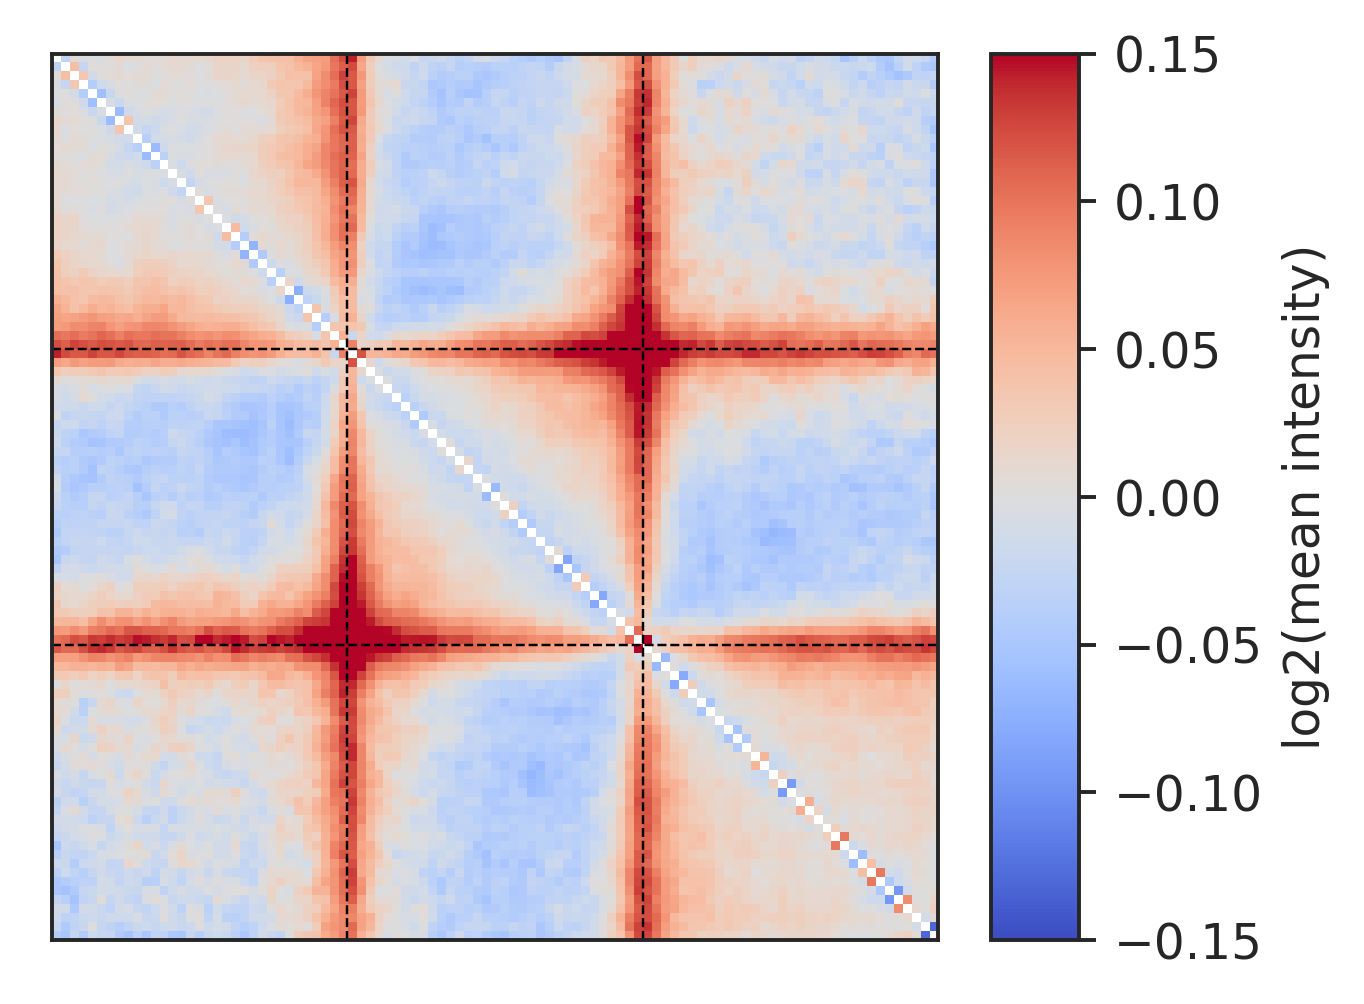

In [15]:
visualize_ratio(av_tad_old, 
                vmin = -0.15, 
                vmax = 0.15)

#### S6-KO vs Adult

In [16]:
tad_file1 = merged_ko[['chr', 'start', 'end']]
tad_file1.columns = ['chrom', 'start', 'end']

tad_file2 = merged_adl[['chr', 'start', 'end']]
tad_file2.columns = ['chrom', 'start', 'end']

resolution = 10000
expected = [expected_ko, expected_adl]

av_tad_ko = create_average_tad_borders_both(tad_file1, tad_file2, ko_clr, wt_clr, expected, resolution)

INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr6_p', 'chr6_p'): 663
INFO:coolpuppy:('chr4_p', 'chr4_p'): 686
INFO:coolpuppy:('chr9_p', 'chr9_p'): 561
INFO:coolpuppy:('chr8_p', 'chr8_p'): 512
INFO:coolpuppy:('chr5_p', 'chr5_p'): 670
INFO:coolpuppy:('chr10_p', 'chr10_p'): 535
INFO:coolpuppy:('chr3_p', 'chr3_p'): 654
INFO:coolpuppy:('chr7_p', 'chr7_p'): 661
INFO:coolpuppy:('chr1_p', 'chr1_p'): 816
INFO:coolpuppy:('chr2_p', 'chr2_p'): 763
INFO:coolpuppy:('chr12_p', 'chr12_p'): 470
INFO:coolpuppy:('chr13_p', 'chr13_p'): 511
INFO:coolpuppy:('chr11_p', 'chr11_p'): 548
INFO:coolpuppy:('chr15_p', 'chr15_p'): 446
INFO:coolpuppy:('chr17_p', 'chr17_p'): 410
INFO:coolpuppy:('chr16_p', 'chr16_p'): 416
INFO:coolpuppy:('chr19_p', 'chr19_p'): 254
INFO:coolpuppy:('chr18_p', 'chr18_p'): 380
INFO:coolpuppy:('chr14_p', 'chr14_p'): 445
INFO:coolpuppy:('chrX_p', 'chrX_p'): 664
INFO:coolpuppy:Total number of piled up windows: 11065
INFO:coolpuppy:Rescaling with rescale_fla

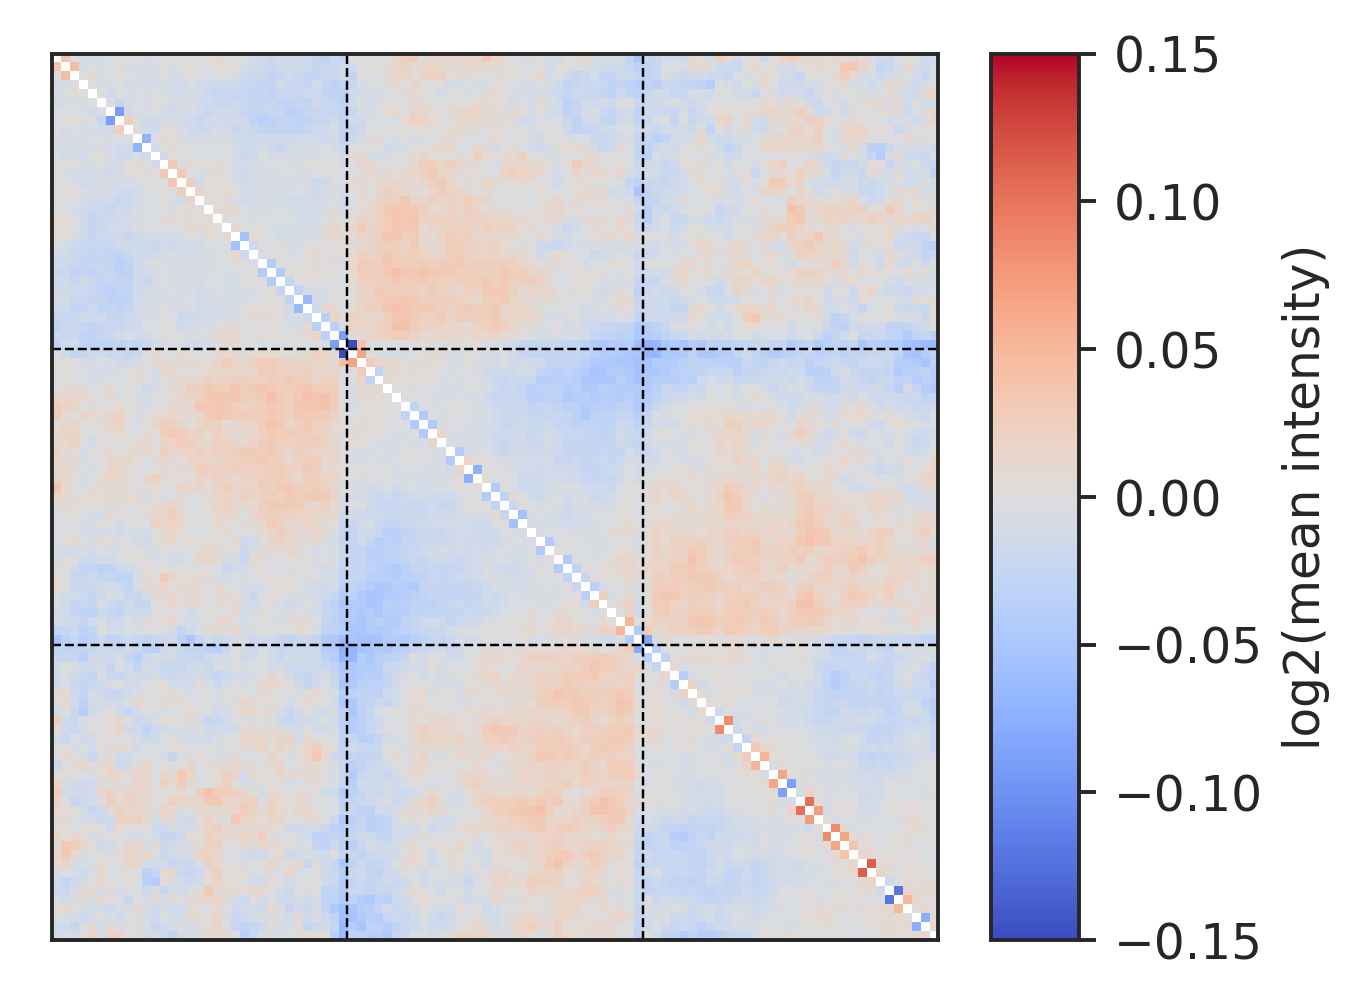

In [17]:
visualize_ratio(av_tad_ko, 
                vmin = -0.15, 
                vmax = 0.15)

#### Step1 vs Control

In [18]:
tad_file1 = merged_s1[['chr', 'start', 'end']]
tad_file1.columns = ['chrom', 'start', 'end']

tad_file2 = merged_con[['chr', 'start', 'end']]
tad_file2.columns = ['chrom', 'start', 'end']

resolution = 10000
expected = [expected_s1, expected_con]

av_tad_s1 = create_average_tad_borders_both(tad_file1, tad_file2, s1_clr, con_clr, expected, resolution)

INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr8_p', 'chr8_p'): 565
INFO:coolpuppy:('chr10_p', 'chr10_p'): 624
INFO:coolpuppy:('chr4_p', 'chr4_p'): 738
INFO:coolpuppy:('chr7_p', 'chr7_p'): 685
INFO:coolpuppy:('chr9_p', 'chr9_p'): 628
INFO:coolpuppy:('chr1_p', 'chr1_p'): 966
INFO:coolpuppy:('chr5_p', 'chr5_p'): 745
INFO:coolpuppy:('chr3_p', 'chr3_p'): 743
INFO:coolpuppy:('chr6_p', 'chr6_p'): 737
INFO:coolpuppy:('chr2_p', 'chr2_p'): 864
INFO:coolpuppy:('chr11_p', 'chr11_p'): 608
INFO:coolpuppy:('chr16_p', 'chr16_p'): 451
INFO:coolpuppy:('chr13_p', 'chr13_p'): 534
INFO:coolpuppy:('chr14_p', 'chr14_p'): 524
INFO:coolpuppy:('chr19_p', 'chr19_p'): 278
INFO:coolpuppy:('chr12_p', 'chr12_p'): 511
INFO:coolpuppy:('chr18_p', 'chr18_p'): 395
INFO:coolpuppy:('chr15_p', 'chr15_p'): 485
INFO:coolpuppy:('chr17_p', 'chr17_p'): 453
INFO:coolpuppy:('chrX_p', 'chrX_p'): 720
INFO:coolpuppy:Total number of piled up windows: 12254
INFO:coolpuppy:Rescaling with rescale_fla

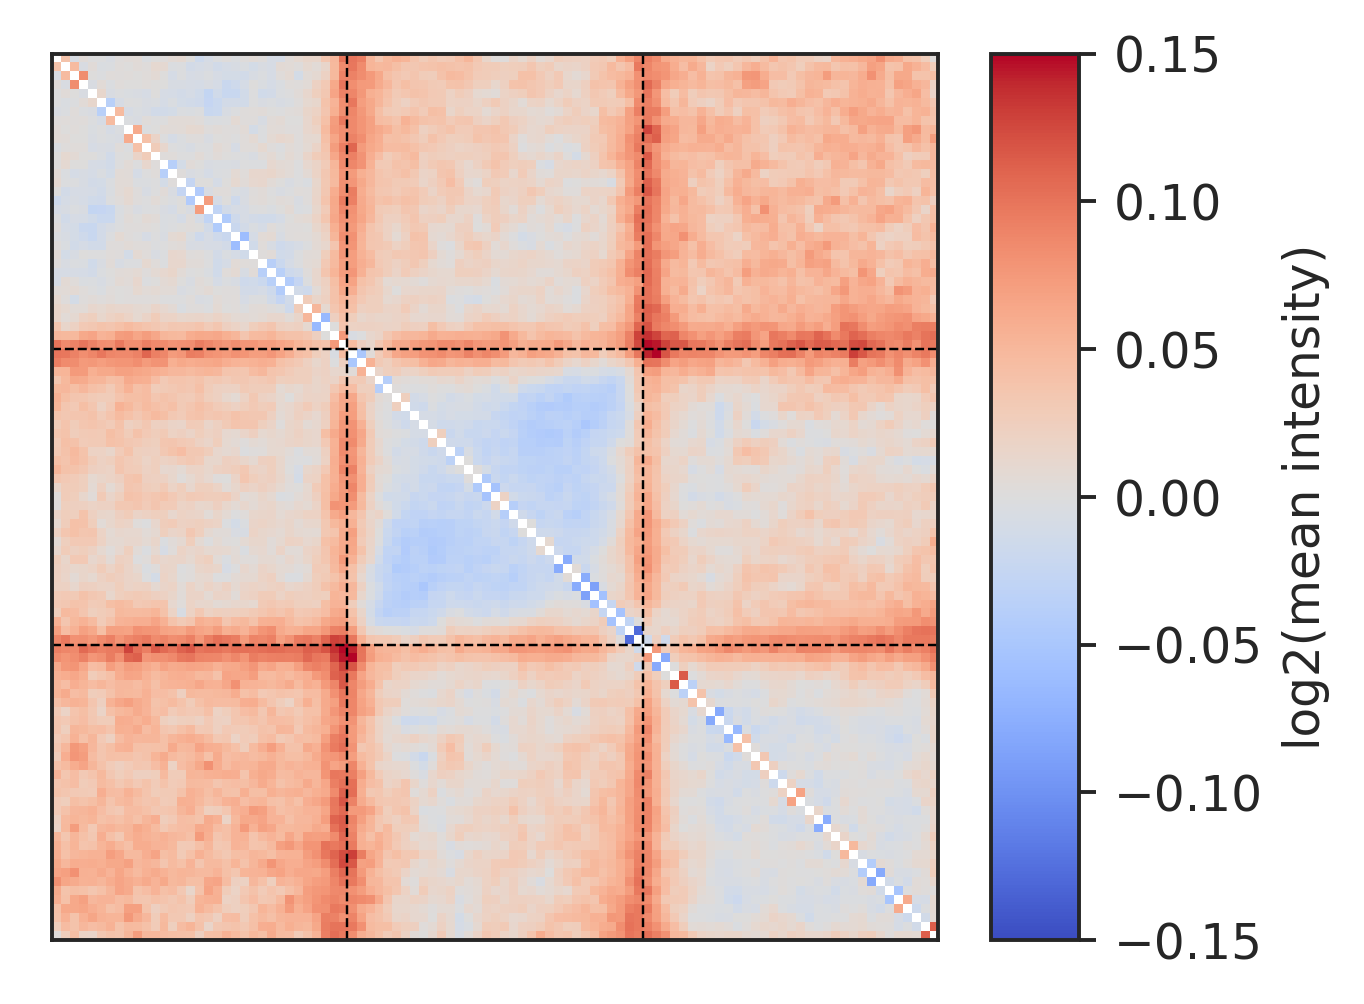

In [19]:
visualize_ratio(av_tad_s1, 
                vmin = -0.15, 
                vmax = 0.15)

#### Step2 vs Control

In [20]:
tad_file1 = merged_s2[['chr', 'start', 'end']]
tad_file1.columns = ['chrom', 'start', 'end']

tad_file2 = merged_con[['chr', 'start', 'end']]
tad_file2.columns = ['chrom', 'start', 'end']

resolution = 10000
expected = [expected_s2, expected_con]

av_tad_s2 = create_average_tad_borders_both(tad_file1, tad_file2, s2_clr, con_clr, expected, resolution)

INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr7_p', 'chr7_p'): 629
INFO:coolpuppy:('chr9_p', 'chr9_p'): 529
INFO:coolpuppy:('chr8_p', 'chr8_p'): 513
INFO:coolpuppy:('chr10_p', 'chr10_p'): 565
INFO:coolpuppy:('chr1_p', 'chr1_p'): 863
INFO:coolpuppy:('chr6_p', 'chr6_p'): 649
INFO:coolpuppy:('chr5_p', 'chr5_p'): 655
INFO:coolpuppy:('chr4_p', 'chr4_p'): 688
INFO:coolpuppy:('chr3_p', 'chr3_p'): 686
INFO:coolpuppy:('chr2_p', 'chr2_p'): 783
INFO:coolpuppy:('chr18_p', 'chr18_p'): 350
INFO:coolpuppy:('chr19_p', 'chr19_p'): 241
INFO:coolpuppy:('chr15_p', 'chr15_p'): 453
INFO:coolpuppy:('chr16_p', 'chr16_p'): 410
INFO:coolpuppy:('chr13_p', 'chr13_p'): 475
INFO:coolpuppy:('chr17_p', 'chr17_p'): 391
INFO:coolpuppy:('chr11_p', 'chr11_p'): 528
INFO:coolpuppy:('chr12_p', 'chr12_p'): 444
INFO:coolpuppy:('chr14_p', 'chr14_p'): 443
INFO:coolpuppy:('chrX_p', 'chrX_p'): 656
INFO:coolpuppy:Total number of piled up windows: 10951
INFO:coolpuppy:Rescaling with rescale_fla

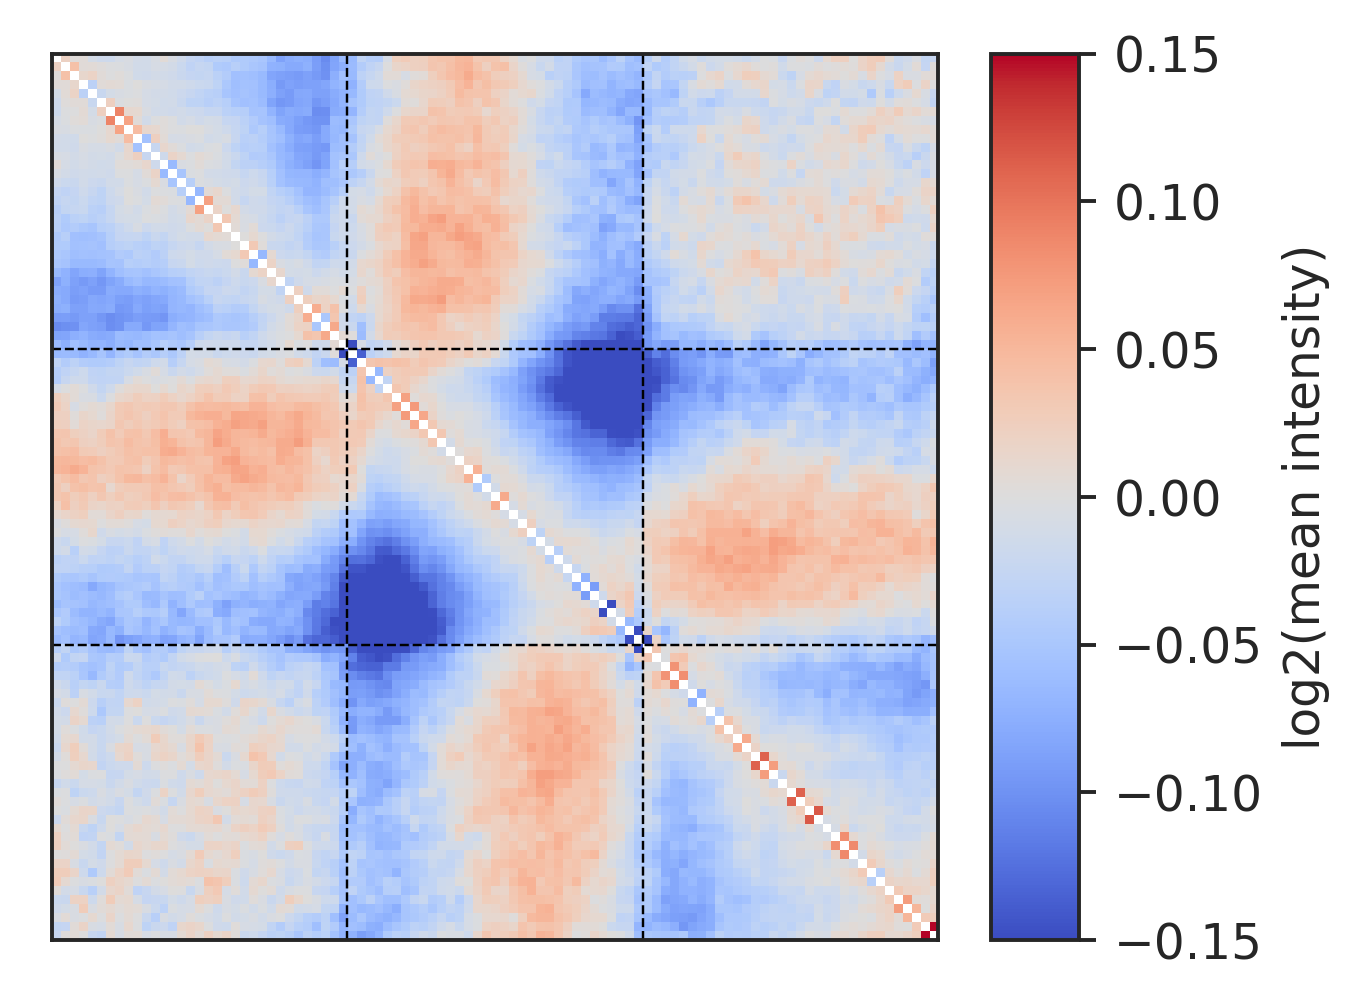

In [21]:
visualize_ratio(av_tad_s2, 
                vmin = -0.15, 
                vmax = 0.15)

All figures

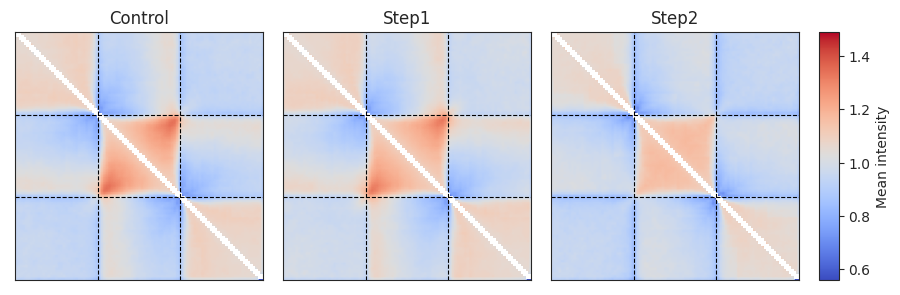

In [22]:
vmin = 0.56
vmax = 1.49

fig, ((ax1, ax2, ax3, axcb)) = plt.subplots(1, 4, figsize = (9.1, 3), gridspec_kw = {'width_ratios':[1, 1, 1, 0.08]})
sns.set_style("ticks")
plt.rcParams['axes.facecolor'] = 'white'

for ax, pileup, samplename in zip([ax1, ax2, ax3], 
                              [av_tad_s1[1], av_tad_s1[0], av_tad_s2[0]], 
                              ["Control", "Step1", "Step2"]):
    
    #visualize_ratio(pileup, vmin = -0.15, vmax = 0.15)

    x_indices, y_indices = create_plot_indices()

    # Compute the ratio of treatment/control
    ratio = pileup
    ratio[ratio == np.inf] = np.nan  # Replace infinities with NaN
    
    # Visualize the treatment/control ratio
    image = ax.imshow(ratio, cmap='coolwarm', vmin=vmin, vmax=vmax)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(samplename)

    for ind in [32.5, 65.5]:
        ax.axhline(y = ind, color = "black", linestyle = "--", linewidth = 0.8)
        ax.axvline(x = ind, color = "black", linestyle = "--", linewidth = 0.8)

cbar = plt.colorbar(image, cax = axcb)

axcb.set_box_aspect(12.5) 
axcb.set_ylabel("Mean intensity")

plt.tight_layout()

#plt.savefig("Stucked_individual_pileups_all_conditions.png", dpi = 600)

### Log2​ ratios of contact intensities, computed from the center of the bottom to the top of the central average TAD triangle in S6-KO/Adult, Old/Adult, Step1/Controo, Step2/Control comparisons

In [23]:
def compute_log_ratio(treatment_data, control_data):
    """ Computes the log2-transformed ratio of treatment over control. """
    ratio = np.divide(treatment_data, control_data, out=np.zeros_like(treatment_data), where=control_data != 0)
    ratio[ratio == np.inf] = np.nan  # Replace infinities with NaN
    log_ratio = np.log2(ratio)  # Use log2 for ratio transformation
    return log_ratio

def extract_scaling_values(log_ratio, start=(50, 50), end=(66, 33)):
    """
    Extracts values along a diagonal path or custom path for scaling.
    Args:
        log_ratio: The matrix of log-transformed ratios.
        start: Starting coordinate for the path (Ox).
        end: Ending coordinate for the path (Oy).
    Returns:
        distances: Distances from the start along the path.
        values: Log-ratio values along the path.
    """
    x, y = start
    end_x, end_y = end
    values = []
    distances = []

    distance = 0
    while x <= end_x and y >= end_y:
        if log_ratio[x, y] != np.nan:
            values.append(log_ratio[x, y])
            distances.append(distance)
        x += 1  # Move one step in the x direction
        y -= 1  # Move one step in the y direction
        distance += 1
    
    return distances, values

In [24]:
log_ratio_old_adl = compute_log_ratio(av_tad_old[0], av_tad_old[1])
log_ratio_ko_adl = compute_log_ratio(av_tad_ko[0], av_tad_ko[1])
log_ratio_s1_con = compute_log_ratio(av_tad_s1[0], av_tad_s1[1])
log_ratio_s2_con = compute_log_ratio(av_tad_s2[0], av_tad_s2[1])

distances_ko, scaling_values_ko = extract_scaling_values(log_ratio_ko_adl)
distances_old, scaling_values_old = extract_scaling_values(log_ratio_old_adl)
distances_s1, scaling_values_s1 = extract_scaling_values(log_ratio_s1_con)
distances_s2, scaling_values_s2 = extract_scaling_values(log_ratio_s2_con)

In [25]:
%load_ext rpy2.ipython

INFO:rpy2.situation:cffi mode is CFFI_MODE.ANY
INFO:rpy2.situation:R home found: /usr/lib/R
INFO:rpy2.situation:R library path: /usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server
INFO:rpy2.situation:LD_LIBRARY_PATH: /usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server
INFO:rpy2.rinterface_lib.embedded:Default options to initialize R: rpy2, --quiet, --no-save
INFO:rpy2.rinterface_lib.embedded:R is already initialized. No need to initialize.



    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

In addition: Warning messages:
1: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
  library ‘/usr/lib/R/site-library’ contains no packages
2: Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 
3: The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


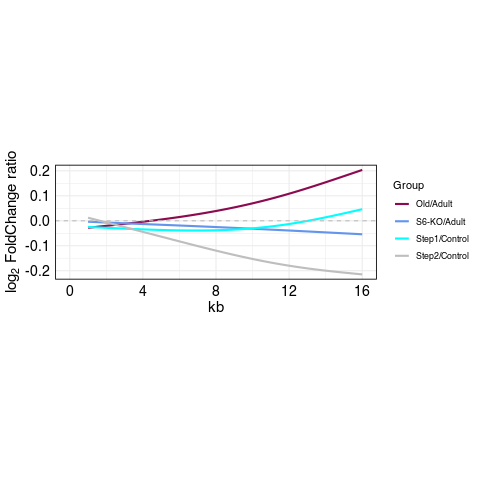

In [26]:
%%R

library(reticulate)
library(splines)
library(ggplot2)

remove_nan_inf <- function(distances, values) {
  valid_indices <- !is.na(values) & is.finite(values)
  return(list(distances[valid_indices], values[valid_indices]))
}

prepare_smooth_data <- function(distances, values, label) {
  filtered_data <- remove_nan_inf(distances, values)
  distances <- filtered_data[[1]]
  values <- filtered_data[[2]]
  
  # Sort and remove duplicates
  sorted_indices <- order(distances)
  distances <- distances[sorted_indices]
  values <- values[sorted_indices]
  
  unique_data <- unique(data.frame(Distance = distances, Log2_Ratio = values))
  
  # Interpolation
  smooth_distances <- seq(min(unique_data$Distance), max(unique_data$Distance), length.out = 300)
  smooth_values <- predict(smooth.spline(unique_data$Distance, unique_data$Log2_Ratio, spar = 0.7), smooth_distances)$y
  
  return(data.frame(Distance = smooth_distances, Log2_Ratio = smooth_values, Group = label))
}


distances          <- as.numeric( unlist(py_eval('distances_ko')) )
scaling_values_ko  <- as.numeric( unlist(py_eval('scaling_values_ko')) )
scaling_values_old <- as.numeric( unlist(py_eval('scaling_values_old')) )
scaling_values_s1 <- as.numeric( unlist(py_eval('scaling_values_s1')) )
scaling_values_s2 <- as.numeric( unlist(py_eval('scaling_values_s2')) )

df_ko <- prepare_smooth_data(distances, scaling_values_ko, "S6-KO/Adult")
df_old <- prepare_smooth_data(distances, scaling_values_old, "Old/Adult")
df_s1 <- prepare_smooth_data(distances, scaling_values_s1, "Step1/Control")
df_s2 <- prepare_smooth_data(distances, scaling_values_s2, "Step2/Control")

df <- rbind(df_ko, df_old, df_s1, df_s2)

ggplot(df, aes(x = Distance, y = Log2_Ratio, color = Group)) +
  geom_line(size = 1) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray") +
  xlab('kb') + ylab(expression(log[2]~FoldChange~ratio)) +
  scale_x_continuous(limits = c(0, 16), breaks = seq(0,16, 4)) +
  #ylim(-0.07, 0.07) +
  theme_minimal() +
  scale_color_manual(values=c('deeppink4', 'cornflowerblue', 'cyan', 'grey')) +
  theme(
    axis.text = element_text(size = 14, color = "black"),
    axis.title = element_text(size = 15, color = "black"),
    panel.border = element_rect(color = "black", fill = NA, size = 0.8),
    aspect.ratio = 1/2.8
  )

#ggsave("tad_lfc_ratio.png", width = 5, height = 3, dpi = 300)

### Ratio of intensities from HiCExplorer

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.4     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


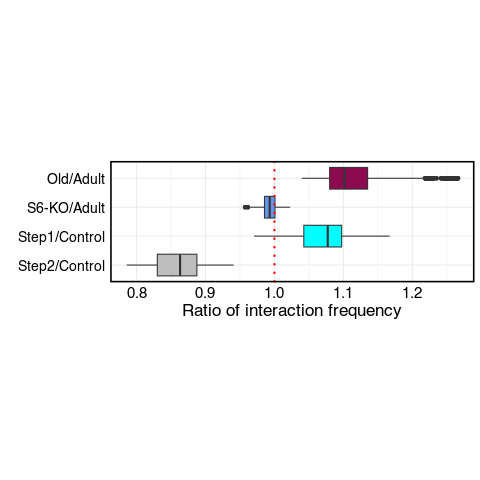

In [27]:
%%R
library(tidyverse)
library(reticulate)

np <- import("numpy")

npz_old <- np$load('/tank/projects/kashuk_sirt6_hic/avTAD/average_old_TADs_center.npz')
npz_ko <- np$load('/tank/projects/kashuk_sirt6_hic/avTAD/average_KO_TADs_center.npz')
npz_adl <- np$load('/tank/projects/kashuk_sirt6_hic/avTAD/average_WT_TADs_center.npz')

npz_s1 <- np$load('/tank/projects/kashuk_sirt6_hic/avTAD/average_step1_TADs_center.npz')
npz_s2 <- np$load('/tank/projects/kashuk_sirt6_hic/avTAD/average_step2_TADs_center.npz')
npz_con <- np$load('/tank/projects/kashuk_sirt6_hic/avTAD/average_control_TADs_center.npz')

data_old <- npz_old$f[["data"]]
data_ko <- npz_ko$f[["data"]]
data_adl <- npz_adl$f[["data"]]

data_s1 <- npz_s1$f[["data"]]
data_s2 <- npz_s2$f[["data"]]
data_con <- npz_con$f[["data"]]

ko_adl <- data_ko/data_adl
old_adl <- data_old/data_adl
s1_con <- data_s1/data_con
s2_con <- data_s2/data_con

df <- data.frame(value = c(ko_adl, old_adl, s1_con, s2_con))
ko_adl_v <- rep(paste0('S6-KO/Adult'), times=length(ko_adl))
old_adl_v <- rep(paste0('Old/Adult'), times=length(old_adl))
s1_con_v <- rep(paste0('Step1/Control'), times=length(s1_con))
s2_con_v <- rep(paste0('Step2/Control'), times=length(s2_con))

df$type <- c(ko_adl_v, old_adl_v, s1_con_v, s2_con_v)
df$type <- factor(df$type, levels=c('Step2/Control', 'Step1/Control', 'S6-KO/Adult', 'Old/Adult'))


m = ggplot(df, aes(x = value, y = type)) +
  geom_boxplot(aes(fill = type), show.legend = FALSE) +
  ylab('') +
  xlab('Ratio of interaction frequency') +
  #xlim(0.6, 1.5) +
  theme_minimal() +
  geom_vline(xintercept=1, linetype='dotted', col = 'red', size=1) +
  theme(axis.text.x=element_text(color = "black",size = 15),
        axis.title.x = element_text(size = 17, colour='black'),
        axis.text.y = element_text(size = 14, colour='black'),
        panel.border = element_rect(colour = "black", fill=NA, size=1.5),
        aspect.ratio = 1/3) +
  scale_fill_manual(values=c('grey', 'cyan', 'cornflowerblue', 'deeppink4', 'cornflowerblue'))

m

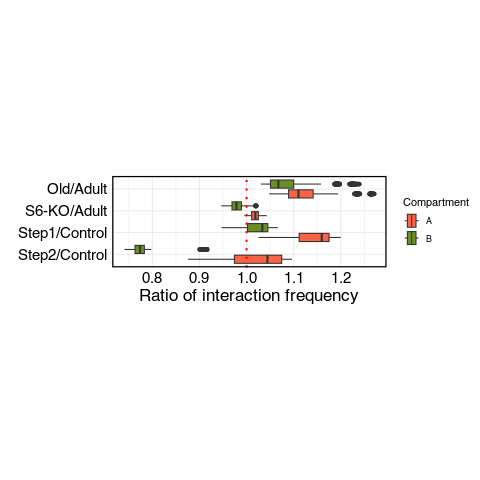

In [28]:
%%R

library(tidyverse)
library(reticulate)

np <- import("numpy")

# LOAD NPZ
npz_old_a <- np$load('/tank/projects/kashuk_sirt6_hic/avTAD/average_old_TADs_comp_A_center.npz')
npz_old_b <- np$load('/tank/projects/kashuk_sirt6_hic/avTAD/average_old_TADs_comp_B_center.npz')

npz_ko_a <- np$load('/tank/projects/kashuk_sirt6_hic/avTAD/average_KO_TADs_comp_A_center.npz')
npz_ko_b <- np$load('/tank/projects/kashuk_sirt6_hic/avTAD/average_KO_TADs_comp_B_center.npz')

npz_adl_a <- np$load('/tank/projects/kashuk_sirt6_hic/avTAD/average_WT_TADs_comp_A_center.npz')
npz_adl_b <- np$load('/tank/projects/kashuk_sirt6_hic/avTAD/average_WT_TADs_comp_B_center.npz')

npz_con_a   <- np$load('/tank/projects/kashuk_sirt6_hic/avTAD/average_con_TADs_comp_A_center.npz')
npz_con_b   <- np$load('/tank/projects/kashuk_sirt6_hic/avTAD/average_con_TADs_comp_B_center.npz')

npz_step1_a <- np$load('/tank/projects/kashuk_sirt6_hic/avTAD/average_step1_TADs_comp_A_center.npz')
npz_step1_b <- np$load('/tank/projects/kashuk_sirt6_hic/avTAD/average_step1_TADs_comp_B_center.npz')

npz_step2_a <- np$load('/tank/projects/kashuk_sirt6_hic/avTAD/average_step2_TADs_comp_A_center.npz')
npz_step2_b <- np$load('/tank/projects/kashuk_sirt6_hic/avTAD/average_step2_TADs_comp_B_center.npz')

# EXTRACT DATA
data_old_a <- npz_old_a$f[["data"]]
data_old_b <- npz_old_b$f[["data"]]

data_ko_a <- npz_ko_a$f[["data"]]
data_ko_b <- npz_ko_b$f[["data"]]

data_adl_a <- npz_adl_a$f[["data"]]
data_adl_b <- npz_adl_b$f[["data"]]

data_con_a   <- npz_con_a$f[["data"]]
data_con_b   <- npz_con_b$f[["data"]]

data_step1_a <- npz_step1_a$f[["data"]]
data_step1_b <- npz_step1_b$f[["data"]]

data_step2_a <- npz_step2_a$f[["data"]]
data_step2_b <- npz_step2_b$f[["data"]]

# RATIOS 
ko_adl_a <- data_ko_a/data_adl_a
ko_adl_b <- data_ko_b/data_adl_b

old_adl_a <- data_old_a/data_adl_a
old_adl_b <- data_old_b/data_adl_b

step1_con_a <- data_step1_a / data_con_a
step1_con_b <- data_step1_b / data_con_b

step2_con_a <- data_step2_a / data_con_a
step2_con_b <- data_step2_b / data_con_b

df <- data.frame(
  value = c(
    ko_adl_a, ko_adl_b,
    old_adl_a, old_adl_b,
    step1_con_a, step1_con_b,
    step2_con_a, step2_con_b
  ),
  type = c(
    rep('S6-KO/Adult', length(ko_adl_a)),
    rep('S6-KO/Adult', length(ko_adl_b)),
    rep('Old/Adult',   length(old_adl_a)),
    rep('Old/Adult',   length(old_adl_b)),
    rep('Step1/Control', length(step1_con_a)),
    rep('Step1/Control', length(step1_con_b)),
    rep('Step2/Control', length(step2_con_a)),
    rep('Step2/Control', length(step2_con_b))
  ),
  compartment = c(
    rep('A', length(ko_adl_a)),
    rep('B', length(ko_adl_b)),
    rep('A', length(old_adl_a)),
    rep('B', length(old_adl_b)),
    rep('A', length(step1_con_a)),
    rep('B', length(step1_con_b)),
    rep('A', length(step2_con_a)),
    rep('B', length(step2_con_b))
  )
)

df$type <- factor(df$type, levels=c('Step2/Control', 'Step1/Control', 'S6-KO/Adult', 'Old/Adult'))

df$compartment <- factor(df$compartment, levels=c('A','B'))


m = ggplot(df, aes(x = value, y = type, fill = compartment)) +
  geom_boxplot(position = position_dodge(width = 0.9)) +
  ylab('') +
  xlab('Ratio of interaction frequency') +
  geom_vline(xintercept=1, linetype='dotted', col='red', size=1) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(color="black", size=15),
    axis.title.x = element_text(size=17, colour='black'),
    axis.text.y = element_text(size=15, colour='black'),
    panel.border = element_rect(colour="black", fill=NA, size=1.2),
    aspect.ratio = 1/3
  ) +
  scale_fill_manual(values=c('tomato1','olivedrab'),
                    name = "Compartment")

print(m)

#ggsave('Ratio_interaction_frequency_A_B_comp.pdf', dpi=1200)

In [29]:
%%R

library(dplyr)

pvals <- df %>%
  group_by(type, compartment) %>%
  summarise(
    p_value = wilcox.test(value, mu = 1)$p.value,
    median_val = median(value),
    .groups = 'drop'
  )

print(pvals)

# A tibble: 8 × 4
  type          compartment   p_value median_val
  <fct>         <fct>           <dbl>      <dbl>
1 Step2/Control A           9.78e- 28      1.04 
2 Step2/Control B           1.68e-256      0.774
3 Step1/Control A           1.68e-256      1.16 
4 Step1/Control B           2.23e- 88      1.03 
5 S6-KO/Adult   A           7.22e-246      1.02 
6 S6-KO/Adult   B           2.07e-210      0.978
7 Old/Adult     A           1.68e-256      1.11 
8 Old/Adult     B           1.68e-256      1.07 


### Inclusion ratio

In [ ]:
import cooler
import numpy as np
import pandas as pd
from tqdm import tqdm


def compute_inclusion_ratio(clr, chrom, tad_start, tad_end, resolution):
    """
    Compute the HOMER-style inclusion ratio (IR) for a single TAD.

    IR = intra-TAD interactions / (TAD-to-flank interactions)
    Flanks are the same size as the TAD, upstream and downstream.
    The denominator is inter-TAD only, so IR is unbounded above
    (dense, well-insulated TADs give IR >> 1), as defined by HOMER.
    """
    tad_size = tad_end - tad_start

    flank_start = max(0, tad_start - tad_size)
    flank_end = min(clr.chromsizes[chrom], tad_end + tad_size)

    try:
        matrix = clr.matrix(balance=True).fetch(
            f"{chrom}:{flank_start}-{flank_end}"
        )
    except Exception:
        return np.nan

    region_start = flank_start
    tad_bin_start = (tad_start - region_start) // resolution
    tad_bin_end = (tad_end - region_start) // resolution

    n = matrix.shape[0]
    tad_bin_end = min(tad_bin_end, n)

    if tad_bin_start >= tad_bin_end:
        return np.nan

    # Intra-TAD interactions
    intra = matrix[tad_bin_start:tad_bin_end, tad_bin_start:tad_bin_end]
    intra_sum = np.nansum(intra)

    # Inter-TAD: TAD vs upstream flank
    upstream = matrix[:tad_bin_start, tad_bin_start:tad_bin_end]
    upstream_sum = np.nansum(upstream)

    # Inter-TAD: TAD vs downstream flank
    downstream = matrix[tad_bin_end:, tad_bin_start:tad_bin_end]
    downstream_sum = np.nansum(downstream)

    inter_sum = upstream_sum + downstream_sum

    # HOMER: IR = intra / inter 
    if inter_sum == 0:
        return np.nan  

    ir = intra_sum / inter_sum
    return ir


def score_tads(cool_file, tad_bed, resolution=10000):
    """
    Score TADs from a BED-like DataFrame using a cooler object.
    """
    clr = cool_file
    tads = tad_bed.copy()

    results = []
    for _, row in tqdm(tads.iterrows(), total=len(tads)):
        chrom, start, end = row["chr"], row["start"], row["end"]

        if chrom not in clr.chromsizes:
            results.append(np.nan)
            continue

        ir = compute_inclusion_ratio(clr, chrom, start, end, resolution)
        results.append(ir)

    tads["inclusion_ratio"] = results
    return tads


df_adl = score_tads(
    cool_file=wt_clr,
    tad_bed=merged_adl,
    resolution=10000,
)

df_old = score_tads(
    cool_file=old_clr,
    tad_bed=merged_old,
    resolution=10000,
)

df_ko = score_tads(
    cool_file=ko_clr,
    tad_bed=merged_ko,
    resolution=10000,
)

df_adl.to_csv("tad_inclusion_ratios_adult.csv", index=False)
df_old.to_csv("tad_inclusion_ratios_old.csv", index=False)
df_ko.to_csv("tad_inclusion_ratios_KO.csv", index=False)


df_con = score_tads(
    cool_file=con_clr,
    tad_bed=merged_con,
    resolution=10000,
)

df_s1 = score_tads(
    cool_file=s1_clr,
    tad_bed=merged_s1,
    resolution=10000,
)

df_s2 = score_tads(
    cool_file=s2_clr,
    tad_bed=merged_s2,
    resolution=10000,
)

df_con.to_csv("tad_inclusion_ratios_con.csv", index=False)
df_s1.to_csv("tad_inclusion_ratios_s1.csv", index=False)
df_s2.to_csv("tad_inclusion_ratios_s2.csv", index=False)

Rows: 11502 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): chr
dbl (3): start, end, inclusion_ratio

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 10790 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): chr
dbl (3): start, end, inclusion_ratio

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 11067 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): chr
dbl (3): start, end, inclusion_ratio

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 11754 Columns: 4
── Co

In addition: Warning messages:
1: Removed 62 rows containing non-finite outside the scale range
(`stat_boxplot()`). 
2: Removed 62 rows containing non-finite outside the scale range
(`stat_boxplot()`). 


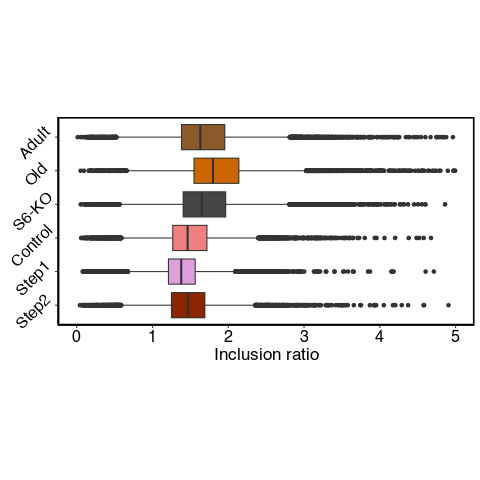

In [33]:
%%R

library(tidyverse)

samples <- list(
  Adult = "tad_inclusion_ratios_adult.csv",
  Old   = "tad_inclusion_ratios_old.csv",
  'S6-KO'  = "tad_inclusion_ratios_KO.csv",
  Control = "tad_inclusion_ratios_con.csv",
  Step1 = "tad_inclusion_ratios_s1.csv",
  Step2 = "tad_inclusion_ratios_s2.csv"
)

combined <- map_dfr(samples, read_csv, .id = "sample") %>%
  mutate(sample = factor(sample, levels = c("Step2", "Step1", "Control", "S6-KO", "Old","Adult")))

combined_filtered <- combined %>% filter(inclusion_ratio > 0)

p <- ggplot(combined_filtered, aes(x = inclusion_ratio, y = sample, fill=sample)) +
  geom_boxplot() +
  theme_classic() +
  xlim(0,5) +
  labs(
    x = "Inclusion ratio",
    y = NULL
  ) + 
  scale_fill_manual(values=c('orangered4', 'plum', 'lightcoral', 'gray27', 'darkorange3', 'tan4')) +
  theme(axis.text.y = element_text(size = 16, colour = 'black', angle=45, hjust=.7),
        axis.text.x = element_text(size = 16, colour = 'black'),
        axis.title.x = element_text(size = 17, colour='black'),
        legend.title = element_blank(),
        legend.position = 'none',
        panel.border = element_rect(colour = "black", fill=NA, size=1.5),
        aspect.ratio = 1/2)

print(p)


ggsave("tad_inclusion_ratios_all_comparisons.pdf", width = 5, height = 4)

In [34]:
%%R

combined_filtered %>%
  group_by(sample) %>%
  summarise(
    n      = n(),
    mean   = mean(inclusion_ratio),
    median = median(inclusion_ratio),
    sd     = sd(inclusion_ratio)
  )

# A tibble: 6 × 5
  sample      n  mean median    sd
  <fct>   <int> <dbl>  <dbl> <dbl>
1 Step2   10667  1.48   1.47 0.436
2 Step1   11986  1.40   1.38 0.413
3 Control 11480  1.51   1.46 0.478
4 S6-KO   10862  1.72   1.65 0.543
5 Old     10654  1.90   1.80 0.636
6 Adult   11323  1.71   1.63 0.576


### Insulation score

In [42]:
%%R

library(ggplot2)
library(dplyr)

merged_adl <- reticulate::py_eval("merged_adl")
merged_old <- reticulate::py_eval("merged_old")
merged_ko <- reticulate::py_eval("merged_ko")
merged_con <- reticulate::py_eval("merged_con")
merged_s1 <- reticulate::py_eval("merged_s1")
merged_s2 <- reticulate::py_eval("merged_s2")

merged_adl$condition <- "Adult"
merged_old$condition <- "Old"
merged_ko$condition  <- "S6-KO"
merged_con$condition  <- "Control"
merged_s1$condition  <- "Step1"
merged_s2$condition  <- "Step2"

# Combine
df_all <- bind_rows(merged_adl, merged_old, merged_ko, merged_con, merged_s1, merged_s2)

head(df_all)

   chr   start     end  ins_score condition
1 chr1 3150000 3669999 -0.7402199     Adult
2 chr1 3670000 4069999 -0.5031549     Adult
3 chr1 4070000 4569999 -0.9724985     Adult
4 chr1 4570000 4759999 -0.7149619     Adult
5 chr1 4760000 5089999 -0.4569647     Adult
6 chr1 5090000 5189999 -0.5472883     Adult


In addition: Warning message:
Removed 1255 rows containing non-finite outside the scale range
(`stat_boxplot()`). 


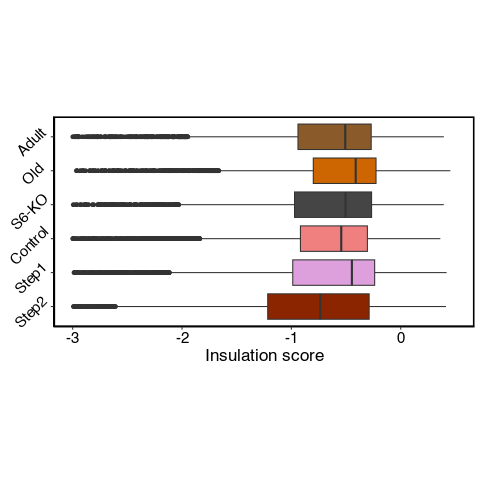

In [43]:
%%R

library(ggplot2)
library(dplyr)

merged_adl <- reticulate::py_eval("merged_adl")
merged_old <- reticulate::py_eval("merged_old")
merged_ko <- reticulate::py_eval("merged_ko")
merged_con <- reticulate::py_eval("merged_con")
merged_s1 <- reticulate::py_eval("merged_s1")
merged_s2 <- reticulate::py_eval("merged_s2")

merged_adl$condition <- "Adult"
merged_old$condition <- "Old"
merged_ko$condition  <- "S6-KO"
merged_con$condition  <- "Control"
merged_s1$condition  <- "Step1"
merged_s2$condition  <- "Step2"

# Combine
df_all <- bind_rows(merged_adl, merged_old, merged_ko, merged_con, merged_s1, merged_s2)

df_all$condition <- factor(df_all$condition, levels=c("Step2", "Step1", "Control", "S6-KO", "Old","Adult"))

# Boxplot
p <- ggplot(df_all, aes(x = ins_score, y = condition, fill=condition)) +
  geom_boxplot() +
  xlim(-3, 0.5) +
  #geom_jitter(width = 0.15, alpha = 0.3, size = 0.8) +
  theme_classic() +
  labs(
    x = "Insulation score",
    y = NULL
  ) + 
  scale_fill_manual(values=c('orangered4', 'plum', 'lightcoral', 'gray27', 'darkorange3', 'tan4')) +
  theme(axis.text.y = element_text(size = 15, colour = 'black', angle=45, hjust=0.7),
        axis.text.x = element_text(size = 15, colour = 'black'),
        axis.title.x = element_text(size = 17, colour='black'),
        legend.title = element_blank(),
        legend.position='none',
        panel.border = element_rect(colour = "black", fill=NA, size=1.5),
        aspect.ratio = 1/2)

print(p)